<a href="https://colab.research.google.com/github/Vyshnavi1429/Rainfall-Prediction-using-Multi-linear-Regression-Model/blob/main/Rainfall_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

**Data Collection and Processing**

In [2]:
# 1. డేటాని లోడ్ చేయడం
# కాలమ్స్ పక్కన స్పేసెస్ ఉంటే పోవడానికి skipinitialspace=True వాడతాం
df = pd.read_csv("/content/sample_data/Rainfall.csv", skipinitialspace=True)

In [3]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [4]:
# కాలమ్ నేమ్స్ ఎలా ఉన్నాయో ప్రింట్ చేసి చూద్దాం
print("Columns in dataset:", df.columns)

Columns in dataset: Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')


In [5]:
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [6]:
df.tail()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9
365,31,1026.4,20.5,17.8,15.5,13.0,74,66,no,5.7,20.0,23.3


In [7]:
print(df)

     day  pressure   maxtemp  temparature  mintemp  dewpoint  humidity   \
0      1     1025.9     19.9         18.3     16.8      13.1         72   
1      2     1022.0     21.7         18.9     17.2      15.6         81   
2      3     1019.7     20.3         19.3     18.0      18.4         95   
3      4     1018.9     22.3         20.6     19.1      18.8         90   
4      5     1015.9     21.3         20.7     20.2      19.9         95   
..   ...        ...      ...          ...      ...       ...        ...   
361   27     1022.7     18.8         17.7     16.9      15.0         84   
362   28     1026.6     18.6         17.3     16.3      12.8         75   
363   29     1025.9     18.9         17.7     16.4      13.3         75   
364   30     1025.3     19.2         17.3     15.2      13.3         78   
365   31     1026.4     20.5         17.8     15.5      13.0         74   

     cloud  rainfall  sunshine  winddirection  windspeed  
0        49      yes       9.3          

In [8]:
print("Data Information")
df.info()

Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            366 non-null    int64  
 1   pressure       366 non-null    float64
 2   maxtemp        366 non-null    float64
 3   temparature    366 non-null    float64
 4   mintemp        366 non-null    float64
 5   dewpoint       366 non-null    float64
 6   humidity       366 non-null    int64  
 7   cloud          366 non-null    int64  
 8   rainfall       366 non-null    object 
 9   sunshine       366 non-null    float64
 10  winddirection  365 non-null    float64
 11  windspeed      365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [9]:
df.columns=df.columns.str.strip()
df['rainfall'] = df['rainfall'].map({'yes': 1, 'no': 0})

In [10]:
X = df[['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'windspeed']]
y = df['rainfall']

In [11]:
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

In [12]:
X = X.fillna(X.mean())
y = y.fillna(0)

In [13]:
print("\n data loaded")


 data loaded


In [14]:
# training data and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} samples")
print(f"Testing data size: {X_test.shape[0]} samples")

Training data size: 292 samples
Testing data size: 74 samples


In [15]:
# 2. Multiple Linear Regression
lr_model = LinearRegression()

In [16]:
df['rainfall'] = df['rainfall'].map({'yes': 1, 'no': 0})

In [17]:
lr_model.fit(X_train, y_train)

print("\nModel Training Completed!")


Model Training Completed!


In [18]:
print("Intercept (Beta 0):", lr_model.intercept_)
print("\nCoefficients for each feature:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"{feature}: {coef}")

Intercept (Beta 0): -0.8539178227386808

Coefficients for each feature:
pressure: 0.0006218634820407713
maxtemp: -0.048352767724745865
temparature: 0.09683930533455545
mintemp: -0.0637587777238425
dewpoint: 0.02578028094512715
humidity: -0.0019323126068747807
cloud: 0.012638329438835059
windspeed: 0.0007579509054352201


In [19]:
y_pred = lr_model.predict(X_test)

In [20]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

In [21]:
print("📊 --- MODEL EVALUATION RESULTS --- 📊\n")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

📊 --- MODEL EVALUATION RESULTS --- 📊

Mean Absolute Error (MAE): 0.2968
Mean Squared Error (MSE): 0.1616
Root Mean Squared Error (RMSE): 0.4019
R-squared (R2) Score: 0.2458


In [22]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted (Probability)': y_pred})
print("\nTop 5 Predictions Comparison:")
print(comparison_df.head())


Top 5 Predictions Comparison:
     Actual  Predicted (Probability)
193       1                 0.977074
33        1                 0.846193
15        1                 0.973697
310       1                 0.864221
57        1                 0.712572


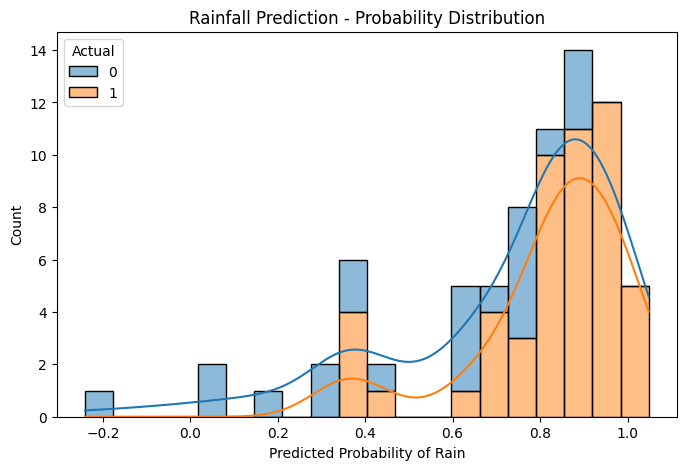

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. యాక్చువల్ vs ప్రెడిక్టెడ్ ప్రాబబిలిటీ డిస్ట్రిబ్యూషన్ గ్రాఫ్
plt.figure(figsize=(8, 5))
sns.histplot(data=comparison_df, x='Predicted (Probability)', hue='Actual', kde=True, bins=20, multiple="stack")
plt.title('Rainfall Prediction - Probability Distribution')
plt.xlabel('Predicted Probability of Rain')
plt.ylabel('Count')
plt.savefig('rainfall_prediction_plot.png') # గ్రాఫ్ ని సేవ్ చేయడానికి

**Exploratory data Analysis (EDA)**